# Project Overview

# DSA 210 - Milestone 2: Spotify Music Analysis

This notebook extends the Milestone 1 exploratory analysis into a reproducible machine learning workflow. The project uses a private Spotify extended streaming history file enriched with Spotify audio features. The raw JSON file is intentionally excluded from GitHub through `.gitignore`; all code below is written so the analysis can be rerun locally when `gulcan_spotify_formatted.json` is placed in the project root.

**Primary ML objective:** predict whether a track is **frequently played** using Spotify audio features and carefully selected non-leaky metadata.

**Target definition:** `frequently_played = 1` if a track appears at least two times in the listening history, otherwise `0`.

**Academic integrity note:** AI assistance was used to improve project organization, preprocessing structure, model comparison code, and report scaffolding. The raw data, project interpretation, and submitted conclusions remain the student's responsibility and are documented in the final report disclosure section.


## Data Loading

The private source file is expected at `gulcan_spotify_formatted.json`. It is not committed to GitHub because it contains personal listening history. The notebook stops with a clear error if the file is missing rather than fabricating data.


In [1]:
from pathlib import Path
import json
import re
import string
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
DATA_FILE = Path("gulcan_spotify_formatted.json")
FIGURE_DIR = Path("reports") / "figures"
IMAGE_DIR = Path("images")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 150, "font.size": 11})


def save_current_figure(filename):
    """Save the active matplotlib figure into reports/figures and images."""
    report_path = FIGURE_DIR / filename
    image_path = IMAGE_DIR / filename
    plt.savefig(report_path, bbox_inches="tight")
    plt.savefig(image_path, bbox_inches="tight")
    print(f"Saved: {report_path}")
    print(f"Saved: {image_path}")


if not DATA_FILE.exists():
    raise FileNotFoundError(
        "Private data file not found. Place gulcan_spotify_formatted.json in the project root "
        "and rerun the notebook. The file is intentionally excluded from GitHub."
    )

with DATA_FILE.open(encoding="utf-8") as f:
    raw = json.load(f)

df = pd.DataFrame(raw)
print(f"Loaded {len(df):,} raw listening records from {DATA_FILE}.")
df.head(3)


Loaded 1,558 raw listening records from gulcan_spotify_formatted.json.


,artistName,trackName,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,endTime
0,Barış Diri,Derinden / bazen hayat çok kötü gidiyor ve ben...,0.668,0.218,11,-13.131,0,0.0478,0.8180,0.001200,0.109,0.0396,129.744,2025-04-11 08:04
1,Isabel LaRosa,HEARTBEAT,0.542,0.729,2,-7.453,1,0.0881,0.0977,0.000009,0.488,0.3370,120.879,2025-04-11 18:27
2,Elley Duhé,MIDDLE OF THE NIGHT,0.410,0.611,4,-8.271,0,0.0467,0.0228,0.000000,0.116,0.0899,185.727,2025-04-11 18:29


## Data Understanding

This section checks the schema, core counts, date range, missing values, and numeric distributions before any modeling decisions are made.


In [2]:
AUDIO_FEATURES = [
    "danceability", "energy", "loudness", "speechiness", "acousticness",
    "instrumentalness", "liveness", "valence", "tempo",
]
OPTIONAL_AUDIO_METADATA = ["key", "mode"]
REQUIRED_COLUMNS = ["artistName", "trackName", "endTime"] + AUDIO_FEATURES

missing_required = [col for col in REQUIRED_COLUMNS if col not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

for col in AUDIO_FEATURES + [c for c in OPTIONAL_AUDIO_METADATA if c in df.columns]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["endTime"] = pd.to_datetime(df["endTime"], errors="coerce")

print(f"Records: {len(df):,}")
print(f"Date range: {df['endTime'].min().date()} to {df['endTime'].max().date()}")
print(f"Unique tracks: {df['trackName'].nunique():,}")
print(f"Unique artists: {df['artistName'].nunique():,}")

missing_summary = df[REQUIRED_COLUMNS + [c for c in OPTIONAL_AUDIO_METADATA if c in df.columns]].isna().sum()
display(missing_summary.to_frame("missing_count"))

display(df[AUDIO_FEATURES].describe().T.round(3))


Records: 1,558
Date range: 2025-04-11 to 2026-04-10
Unique tracks: 1,535
Unique artists: 921


,missing_count
artistName,0
trackName,0
endTime,0
danceability,0
energy,0
loudness,0
speechiness,0
acousticness,0
instrumentalness,0
liveness,0


,count,mean,std,min,25%,50%,75%,max
danceability,1558.0,0.481,0.173,0.068,0.360,0.491,0.601,0.950
energy,1558.0,0.559,0.280,0.002,0.324,0.592,0.798,0.997
loudness,1558.0,-9.365,5.703,-42.041,-12.213,-7.969,-5.218,-0.413
speechiness,1558.0,0.066,0.057,0.023,0.035,0.045,0.070,0.474
acousticness,1558.0,0.374,0.367,0.000,0.023,0.230,0.736,0.996
instrumentalness,1558.0,0.217,0.355,0.000,0.000,0.000,0.368,0.985
liveness,1558.0,0.175,0.128,0.035,0.098,0.121,0.221,0.979
valence,1558.0,0.347,0.227,0.000,0.158,0.310,0.504,0.975
tempo,1558.0,121.270,32.921,49.452,94.045,119.990,144.470,209.873


Saved: reports\figures\feature_distributions.png
Saved: images\feature_distributions.png


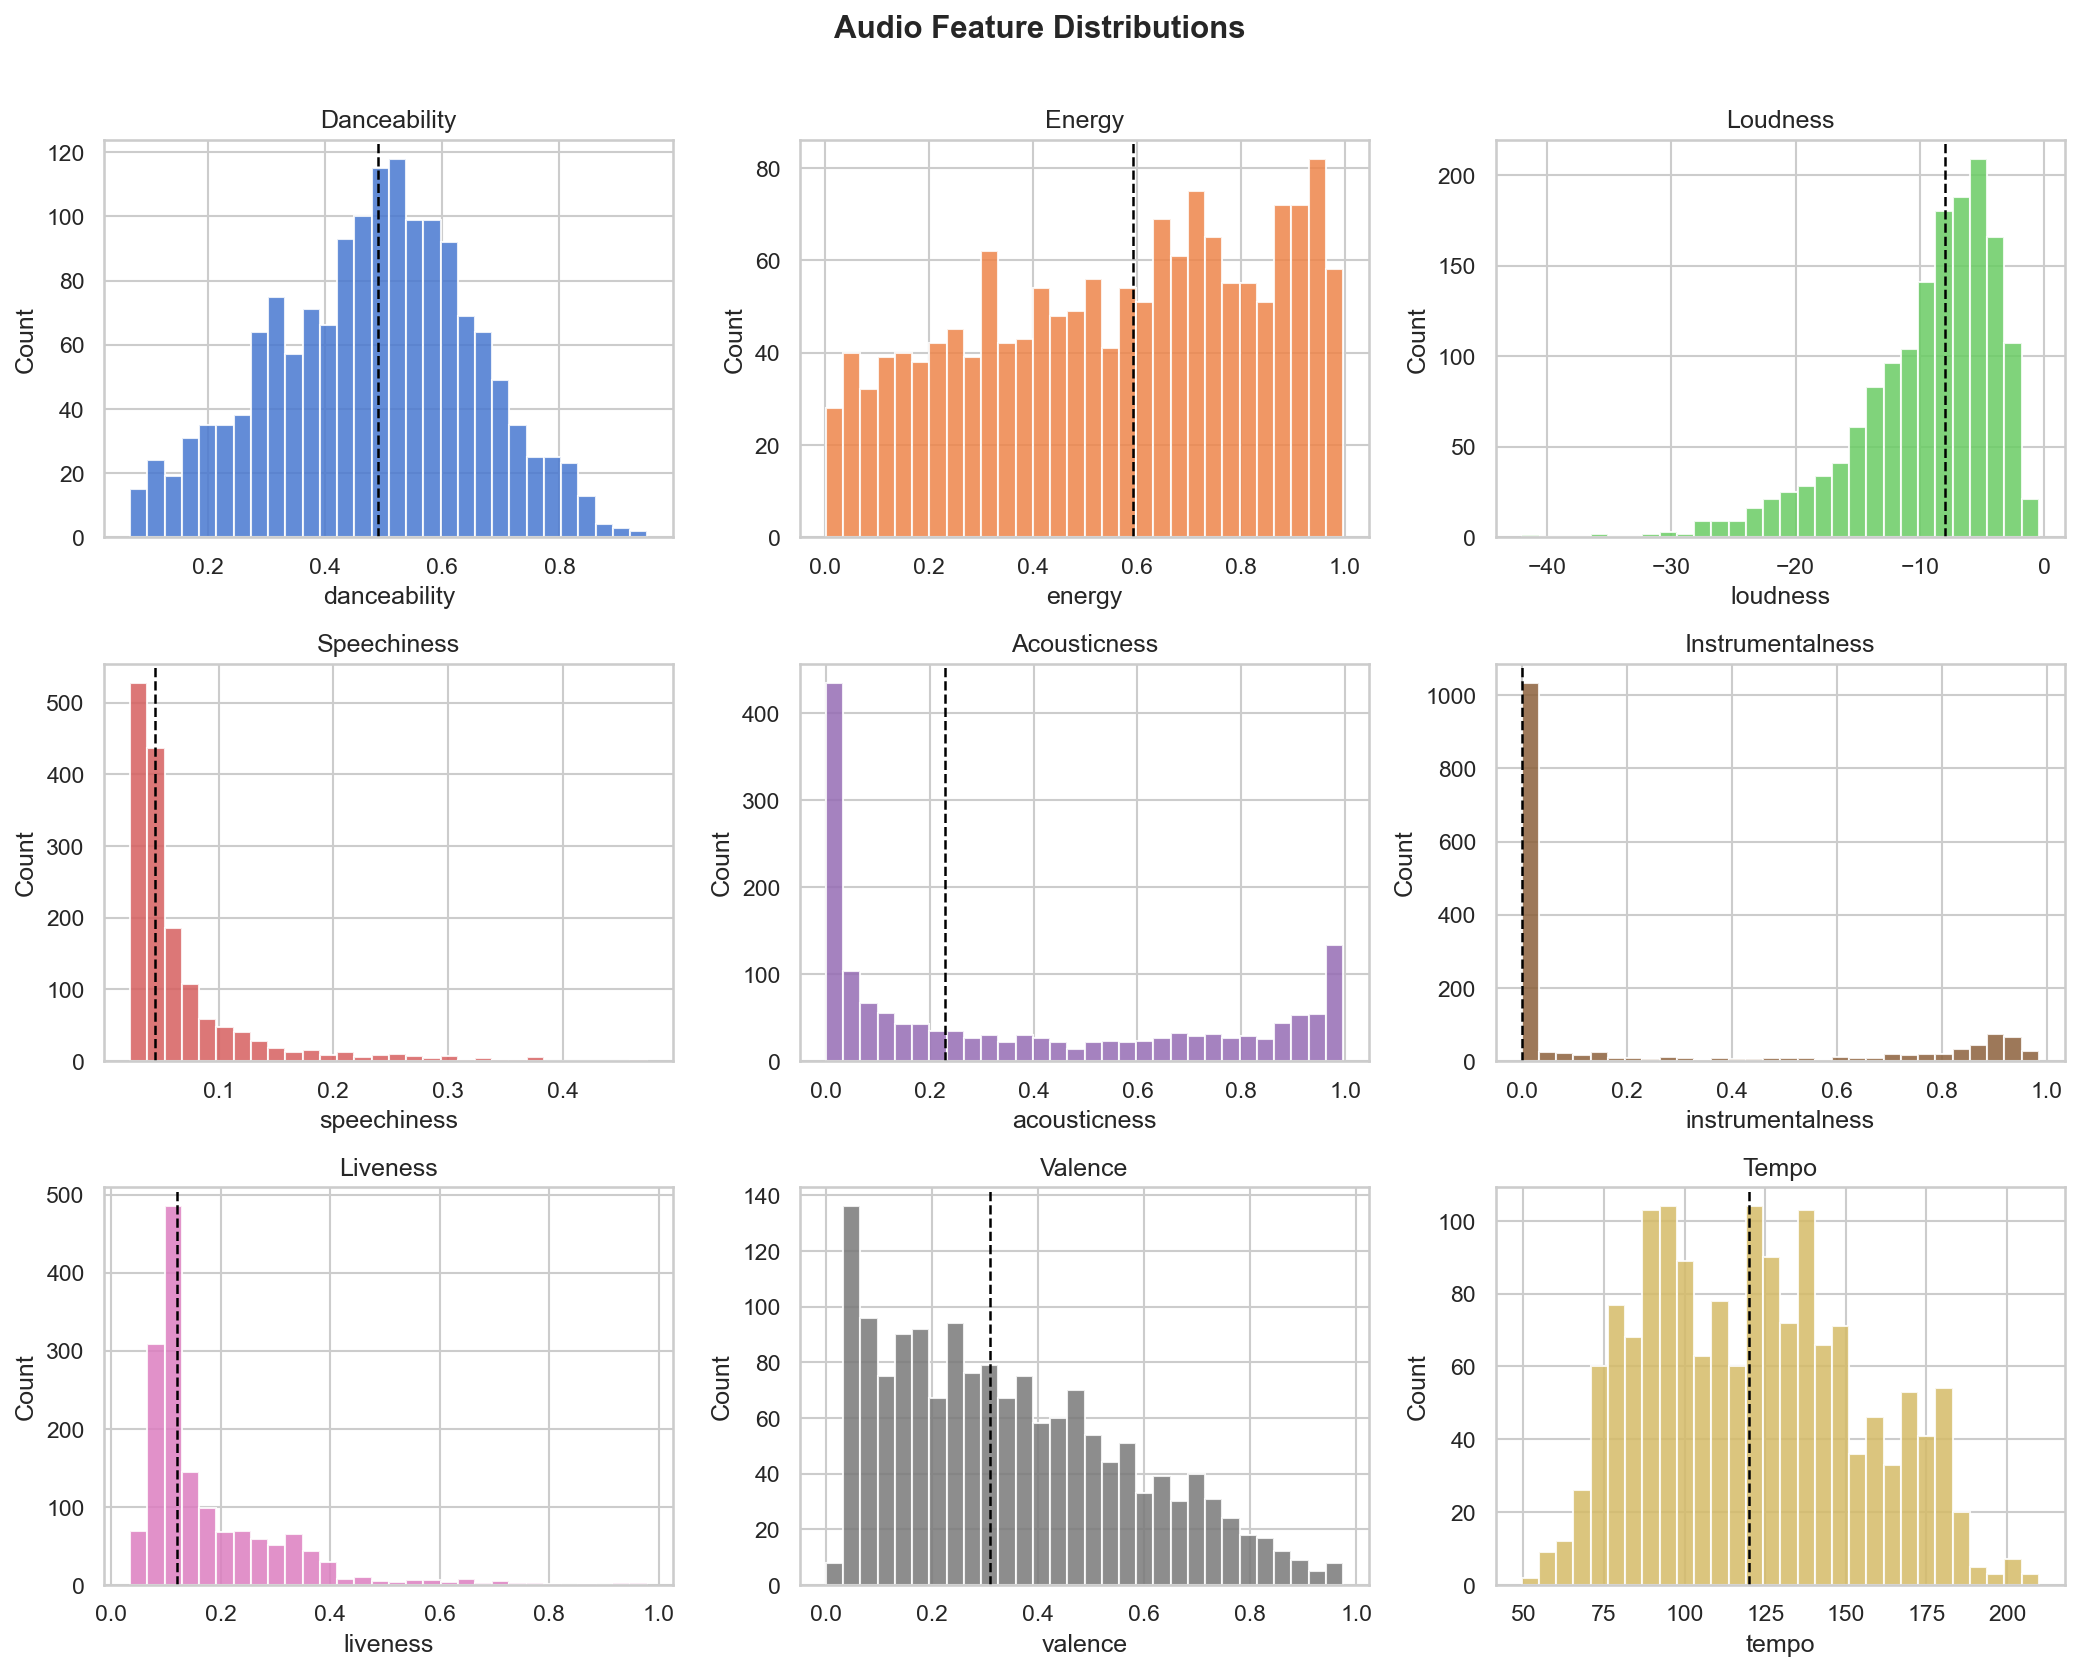

Saved: reports\figures\correlation_heatmap.png
Saved: images\correlation_heatmap.png


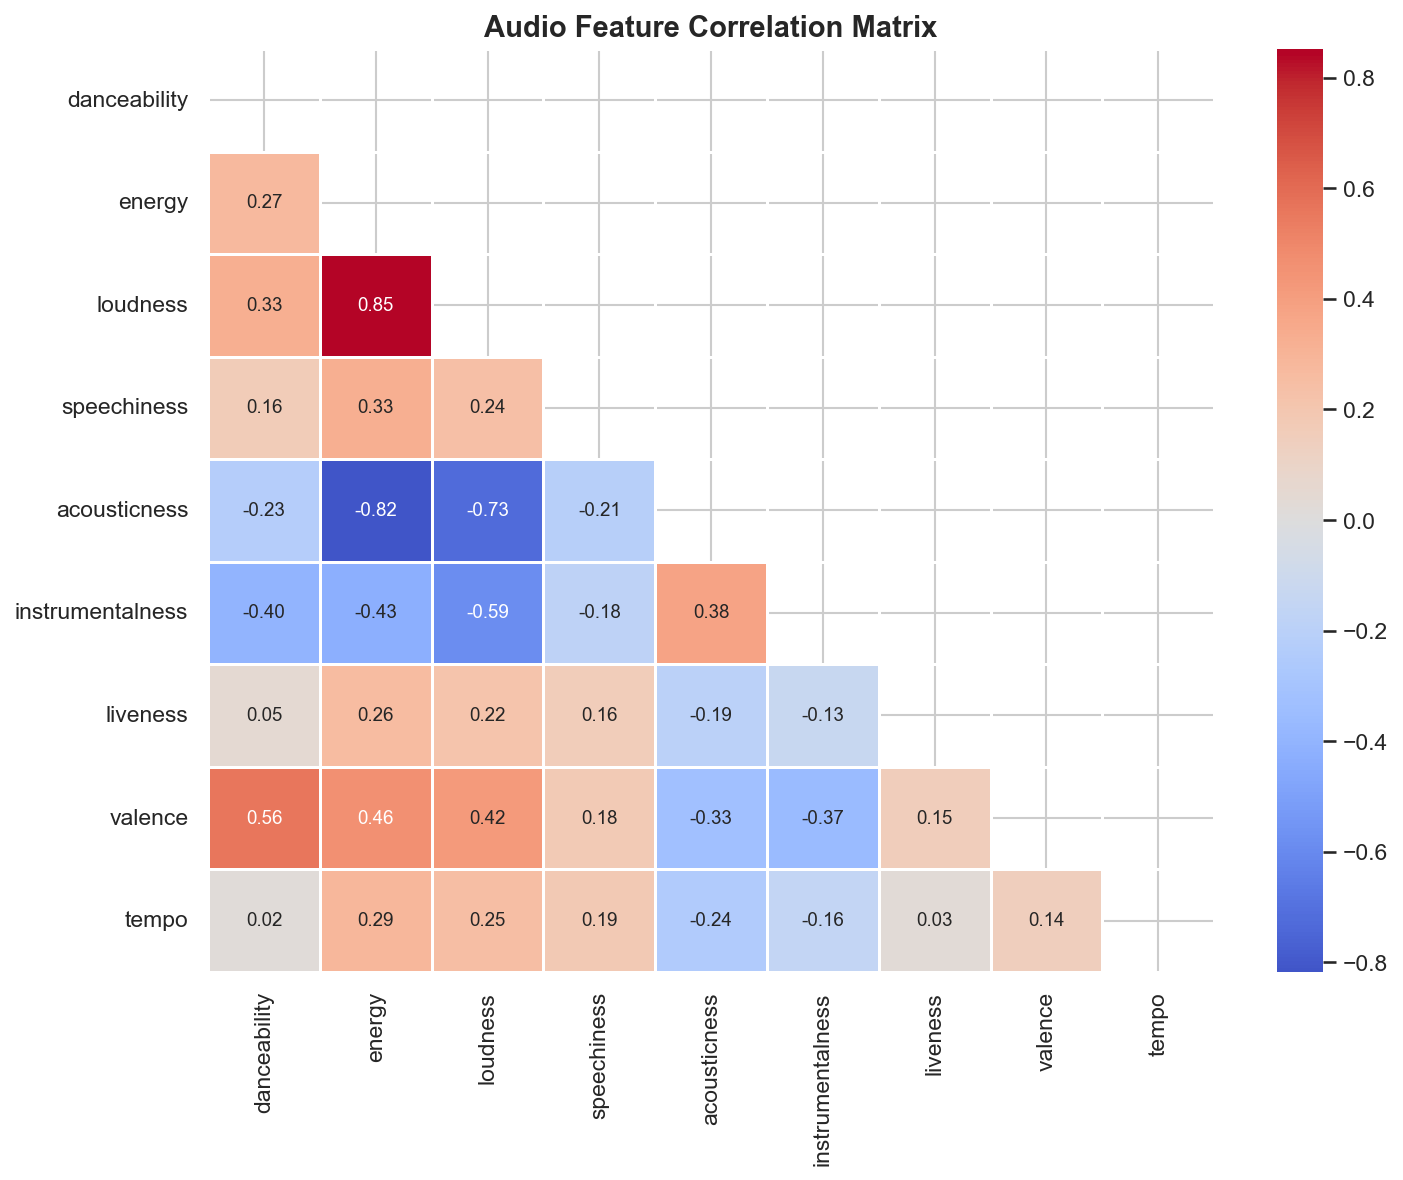

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
axes = axes.flatten()
colors = sns.color_palette("muted", len(AUDIO_FEATURES))

for i, feature in enumerate(AUDIO_FEATURES):
    series = df[feature].dropna()
    axes[i].hist(series, bins=30, color=colors[i], edgecolor="white", alpha=0.85)
    axes[i].axvline(series.median(), color="black", linestyle="--", linewidth=1.2)
    axes[i].set_title(feature.replace("_", " ").title())
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Count")

plt.suptitle("Audio Feature Distributions", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
save_current_figure("feature_distributions.png")
plt.show()

corr = df[AUDIO_FEATURES].corr()
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, ax=ax, annot_kws={"size": 9})
ax.set_title("Audio Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
save_current_figure("correlation_heatmap.png")
plt.show()


## Data Cleaning

Cleaning is intentionally conservative. Personal listening records are retained unless required identifiers or timestamps are missing. Numeric audio features are coerced to numeric values, duplicate rows are removed, and missing values are left for the sklearn preprocessing pipeline to impute inside cross-validation folds.


In [4]:
initial_rows = len(df)

df_clean = df.copy()
df_clean["artistName"] = df_clean["artistName"].astype("string").str.strip()
df_clean["trackName"] = df_clean["trackName"].astype("string").str.strip()

df_clean = df_clean.dropna(subset=["artistName", "trackName", "endTime"])
df_clean = df_clean.drop_duplicates()

print(f"Rows before cleaning: {initial_rows:,}")
print(f"Rows after cleaning: {len(df_clean):,}")
print(f"Rows removed: {initial_rows - len(df_clean):,}")

numeric_missing = df_clean[AUDIO_FEATURES].isna().sum().sort_values(ascending=False)
display(numeric_missing.to_frame("missing_numeric_values"))


Rows before cleaning: 1,558
Rows after cleaning: 1,558
Rows removed: 0


,missing_numeric_values
danceability,0
energy,0
loudness,0
speechiness,0
acousticness,0
instrumentalness,0
liveness,0
valence,0
tempo,0


## Preprocessing

The preprocessing design follows these rules:

- Numeric audio variables are checked for missingness and skewness.
- Strongly skewed positive numeric variables are log-transformed using `log1p`, selected from the training split only.
- Numeric variables are scaled inside sklearn pipelines.
- Binary categorical variables such as Spotify `mode` are imputed and passed as 0/1 values.
- Non-binary categorical variables such as Spotify `key` are one-hot encoded.
- Text columns are detected and normalized; track/artist text is prepared for optional TF-IDF analysis but excluded from the primary models because it can memorize identity-like metadata rather than audio preference patterns.
- Date/time variables are engineered for analysis but excluded from the primary predictive feature set to reduce temporal leakage from listening opportunity.


In [5]:
try:
    import nltk
    from nltk.stem import WordNetLemmatizer
    nltk.data.find("corpora/wordnet")
    LEMMATIZER = WordNetLemmatizer()
    LEMMATIZATION_AVAILABLE = True
except Exception:
    LEMMATIZER = None
    LEMMATIZATION_AVAILABLE = False


def normalize_text(value):
    """Lowercase, remove punctuation, remove English stopwords, and lemmatize when NLTK WordNet is available."""
    text = "" if pd.isna(value) else str(value).lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = [token for token in re.split(r"\s+", text) if token and token not in ENGLISH_STOP_WORDS]
    if LEMMATIZER is not None:
        tokens = [LEMMATIZER.lemmatize(token) for token in tokens]
    return " ".join(tokens)


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


text_columns = [col for col in ["trackName", "artistName"] if col in df_clean.columns]
print(f"Text columns detected: {text_columns if text_columns else 'none'}")
print("Text normalization uses lowercase, punctuation removal, stopword removal, and lemmatization when WordNet is available.")
print(f"Lemmatization available in this environment: {LEMMATIZATION_AVAILABLE}")
print("TF-IDF is prepared for optional analysis, but excluded from the primary non-leaky ML feature set.")

text_vectorizer = TfidfVectorizer(max_features=250, ngram_range=(1, 2), min_df=2)


Text columns detected: ['trackName', 'artistName']
Text normalization uses lowercase, punctuation removal, stopword removal, and lemmatization when WordNet is available.
Lemmatization available in this environment: False
TF-IDF is prepared for optional analysis, but excluded from the primary non-leaky ML feature set.


## Feature Engineering

The event-level data is converted to a track-level modeling table. The label is derived from the total number of plays per track, while predictive features are restricted to audio features and safe Spotify metadata. Leakage-prone variables are created for auditability but explicitly excluded from the main model input.


In [6]:
df_features = df_clean.copy()
df_features["year"] = df_features["endTime"].dt.year
df_features["month"] = df_features["endTime"].dt.month
df_features["day"] = df_features["endTime"].dt.day
df_features["weekday"] = df_features["endTime"].dt.weekday
df_features["hour"] = df_features["endTime"].dt.hour
df_features["is_weekend"] = df_features["weekday"].isin([5, 6]).astype(int)


def first_mode(series):
    mode_values = series.dropna().mode()
    if len(mode_values) == 0:
        return np.nan
    return mode_values.iloc[0]

agg_dict = {
    "play_count": ("trackName", "count"),
    "artistName": ("artistName", first_mode),
    "first_play_time": ("endTime", "min"),
    "last_play_time": ("endTime", "max"),
}
for feature in AUDIO_FEATURES:
    agg_dict[feature] = (feature, "mean")
if "key" in df_features.columns:
    agg_dict["key"] = ("key", first_mode)
if "mode" in df_features.columns:
    agg_dict["mode"] = ("mode", first_mode)

track_ml = (
    df_features
    .groupby(["trackName"], dropna=False)
    .agg(**agg_dict)
    .reset_index()
)

track_ml["frequently_played"] = (track_ml["play_count"] >= 2).astype(int)
track_ml["first_month"] = track_ml["first_play_time"].dt.month
track_ml["first_weekday"] = track_ml["first_play_time"].dt.weekday
track_ml["first_hour"] = track_ml["first_play_time"].dt.hour
track_ml["text_metadata_clean"] = (
    track_ml["trackName"].fillna("").map(normalize_text) + " " +
    track_ml["artistName"].fillna("").map(normalize_text)
).str.strip()

leakage_excluded = [
    "play_count", "first_play_time", "last_play_time", "first_month", "first_weekday",
    "first_hour", "trackName", "artistName", "text_metadata_clean",
]

print(f"Track-level rows: {len(track_ml):,}")
print("Leakage-prone or identity-like fields excluded from primary ML features:")
for col in leakage_excluded:
    print(f"- {col}")

display(track_ml.head())


Track-level rows: 1,535
Leakage-prone or identity-like fields excluded from primary ML features:
- play_count
- first_play_time
- last_play_time
- first_month
- first_weekday
- first_hour
- trackName
- artistName
- text_metadata_clean


,trackName,play_count,artistName,first_play_time,last_play_time,danceability,energy,loudness,speechiness,acousticness,...,liveness,valence,tempo,key,mode,frequently_played,first_month,first_weekday,first_hour,text_metadata_clean
0,42,1,Diplo,2026-04-02 21:33:00,2026-04-02 21:33:00,0.776,0.796,-4.063,0.0370,0.031800,...,0.3900,0.5480,123.983,5,0,0,4,3,21,42 diplo
1,4N,1,Hiroyuki Sawano,2025-06-19 16:09:00,2025-06-19 16:09:00,0.290,0.422,-11.963,0.0379,0.030800,...,0.1100,0.0685,126.057,9,0,0,6,3,16,4n hiroyuki sawano
2,7 rings,1,Ariana Grande,2025-09-30 22:31:00,2025-09-30 22:31:00,0.778,0.317,-10.732,0.3340,0.592000,...,0.0881,0.3270,140.048,1,0,0,9,1,22,7 rings ariana grande
3,74,1,糸奇はな,2025-06-17 02:07:00,2025-06-17 02:07:00,0.590,0.738,-4.877,0.0708,0.684000,...,0.1430,0.4810,94.996,7,1,0,6,1,2,74 糸奇はな
4,7DS against Supreme Deity,1,KOHTA YAMAMOTO,2025-04-26 23:39:00,2025-04-26 23:39:00,0.147,0.726,-9.081,0.0551,0.000964,...,0.0887,0.1020,84.604,11,0,0,4,5,23,7ds supreme deity kohta yamamoto


,track_count
frequently_played,
not frequently played,1513
frequently played,22


Saved: reports\figures\target_distribution.png
Saved: images\target_distribution.png


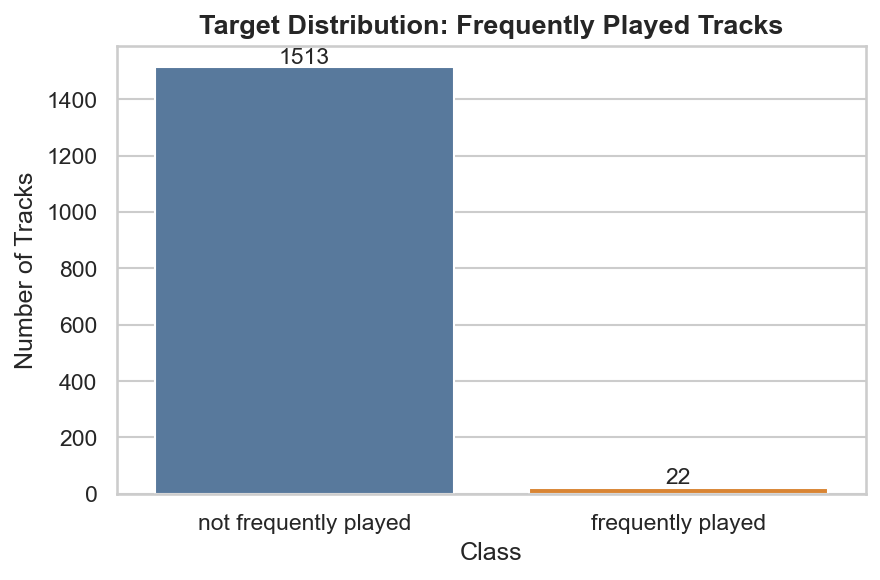

Minority class share: 0.014
Class imbalance detected. Stratified splitting and F1-oriented tuning will be used.


In [7]:
class_counts = track_ml["frequently_played"].value_counts().sort_index()
class_distribution = class_counts.rename(index={0: "not frequently played", 1: "frequently played"})
display(class_distribution.to_frame("track_count"))

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=class_distribution.index, y=class_distribution.values, ax=ax, palette=["#4C78A8", "#F58518"])
ax.set_title("Target Distribution: Frequently Played Tracks", fontsize=13, fontweight="bold")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Tracks")
for idx, value in enumerate(class_distribution.values):
    ax.text(idx, value, str(value), ha="center", va="bottom")
plt.tight_layout()
save_current_figure("target_distribution.png")
plt.show()

minority_share = class_counts.min() / class_counts.sum()
print(f"Minority class share: {minority_share:.3f}")
if minority_share < 0.35:
    print("Class imbalance detected. Stratified splitting and F1-oriented tuning will be used.")
else:
    print("Class distribution is not severely imbalanced. Stratified splitting is still used for consistency.")


## Train/Test Split

All models use the same stratified train/test split. Skewness-based log-transform selection is computed only on `X_train` to avoid train-test leakage.


In [8]:
numeric_features = [feature for feature in AUDIO_FEATURES if feature in track_ml.columns]
binary_features = [feature for feature in ["mode"] if feature in track_ml.columns]
nominal_features = [feature for feature in ["key"] if feature in track_ml.columns]
primary_features = numeric_features + binary_features + nominal_features

X = track_ml[primary_features].copy()
y = track_ml["frequently_played"].copy()

if y.nunique() != 2:
    raise ValueError("The target must contain both classes for binary classification.")
if y.value_counts().min() < 2:
    raise ValueError("Each class needs at least two observations for stratified train/test splitting.")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

train_skew = X_train[numeric_features].skew(numeric_only=True).sort_values(ascending=False)
log_numeric_features = [
    col for col in numeric_features
    if abs(train_skew[col]) > 1 and X_train[col].dropna().ge(0).all()
]
regular_numeric_features = [col for col in numeric_features if col not in log_numeric_features]

print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")
print("Numeric skewness measured on X_train only:")
display(train_skew.to_frame("train_skewness").round(3))
print(f"log1p numeric features: {log_numeric_features if log_numeric_features else 'none'}")
print(f"regular numeric features: {regular_numeric_features}")
print(f"binary categorical features: {binary_features if binary_features else 'none'}")
print(f"nominal categorical features: {nominal_features if nominal_features else 'none'}")


Training rows: 1,228
Test rows: 307
Numeric skewness measured on X_train only:


,train_skewness
speechiness,2.923
liveness,2.293
instrumentalness,1.182
valence,0.522
acousticness,0.519
tempo,0.266
danceability,-0.145
energy,-0.276
loudness,-1.285


log1p numeric features: ['speechiness', 'instrumentalness', 'liveness']
regular numeric features: ['danceability', 'energy', 'loudness', 'acousticness', 'valence', 'tempo']
binary categorical features: ['mode']
nominal categorical features: ['key']


In [9]:
transformers = []

if log_numeric_features:
    log_numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("log1p", FunctionTransformer(np.log1p, validate=False)),
        ("scaler", StandardScaler()),
    ])
    transformers.append(("log_numeric", log_numeric_pipeline, log_numeric_features))

if regular_numeric_features:
    regular_numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    transformers.append(("regular_numeric", regular_numeric_pipeline, regular_numeric_features))

if binary_features:
    binary_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ])
    transformers.append(("binary", binary_pipeline, binary_features))

if nominal_features:
    nominal_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_one_hot_encoder()),
    ])
    transformers.append(("nominal", nominal_pipeline, nominal_features))

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop",
    sparse_threshold=0,
)

print("Preprocessing pipeline ready. It will be fit inside each cross-validation fold.")


Preprocessing pipeline ready. It will be fit inside each cross-validation fold.


## Model Training

The problem is binary classification. The baseline and comparison models cover linear, probabilistic, tree-based, margin-based, bagging, and boosting approaches.


In [10]:
min_class_count = y_train.value_counts().min()
n_splits = int(min(5, min_class_count))
if n_splits < 2:
    raise ValueError("Not enough minority-class observations for cross-validation.")

cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
primary_scoring = "f1" if minority_share < 0.35 else "accuracy"
print(f"Cross-validation folds: {n_splits}")
print(f"Primary tuning metric: {primary_scoring}")

model_configs = {
    "Logistic Regression": {
        "estimator": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        "params": {
            "model__C": [0.1, 1.0, 10.0],
            "model__class_weight": [None, "balanced"],
        },
        "notes": "Linear baseline with regularization and optional class weighting.",
        "strengths": "Interpretable coefficients; strong baseline for standardized audio features.",
        "weaknesses": "May miss nonlinear relationships between audio features and repeat listening.",
    },
    "Naive Bayes": {
        "estimator": GaussianNB(),
        "params": {
            "model__var_smoothing": [1e-9, 1e-8, 1e-7],
        },
        "notes": "Probabilistic baseline with a Gaussian likelihood assumption.",
        "strengths": "Fast and useful as a simple benchmark on small datasets.",
        "weaknesses": "Assumes conditional independence and Gaussian feature distributions.",
    },
    "Decision Tree": {
        "estimator": DecisionTreeClassifier(random_state=RANDOM_STATE),
        "params": {
            "model__max_depth": [2, 3, 5, None],
            "model__min_samples_leaf": [1, 5, 10],
            "model__class_weight": [None, "balanced"],
        },
        "notes": "Nonlinear tree model tuned for depth and leaf size.",
        "strengths": "Easy to interpret and captures feature thresholds.",
        "weaknesses": "Can overfit when unconstrained.",
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [5, 10, None],
            "model__min_samples_leaf": [1, 5],
            "model__class_weight": [None, "balanced"],
        },
        "notes": "Bagging ensemble of decision trees.",
        "strengths": "Robust nonlinear model with feature importance.",
        "weaknesses": "Less transparent than a single tree and can still struggle with severe imbalance.",
    },
    "Support Vector Machine": {
        "estimator": SVC(probability=True, random_state=RANDOM_STATE),
        "params": {
            "model__C": [0.1, 1.0, 10.0],
            "model__kernel": ["linear", "rbf"],
            "model__class_weight": [None, "balanced"],
        },
        "notes": "Margin-based classifier with linear and RBF kernels.",
        "strengths": "Effective in compact feature spaces after scaling.",
        "weaknesses": "Less interpretable and can be sensitive to tuning choices.",
    },
    "Gradient Boosting": {
        "estimator": GradientBoostingClassifier(random_state=RANDOM_STATE),
        "params": {
            "model__n_estimators": [50, 100],
            "model__learning_rate": [0.05, 0.10],
            "model__max_depth": [2, 3],
        },
        "notes": "Sequential boosting ensemble for nonlinear patterns.",
        "strengths": "Often strong on tabular data with interactions.",
        "weaknesses": "Can overfit if too many weak learners are used.",
    },
    "AdaBoost": {
        "estimator": AdaBoostClassifier(random_state=RANDOM_STATE),
        "params": {
            "model__n_estimators": [50, 100],
            "model__learning_rate": [0.05, 0.10, 0.50],
        },
        "notes": "Boosting ensemble using adaptive reweighting.",
        "strengths": "Useful aggregation method for weak learners.",
        "weaknesses": "Can be sensitive to noisy observations and outliers.",
    },
}


Cross-validation folds: 5
Primary tuning metric: f1


## Hyperparameter Tuning

Each model is wrapped in the same sklearn `Pipeline` so preprocessing is fit only on training folds during cross-validation. This prevents leakage from imputation, scaling, one-hot encoding, and log-transform decisions.


In [11]:
tuned_models = {}
grid_summaries = []

for model_name, config in model_configs.items():
    print(f"\nTuning {model_name}...")
    pipeline = Pipeline(steps=[
        ("preprocess", clone(preprocessor)),
        ("model", config["estimator"]),
    ])
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=config["params"],
        scoring=primary_scoring,
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=True,
    )
    grid.fit(X_train, y_train)
    tuned_models[model_name] = grid.best_estimator_
    grid_summaries.append({
        "Model name": model_name,
        "Best parameters": {k.replace("model__", ""): v for k, v in grid.best_params_.items()},
        "CV score": grid.best_score_,
        "Training notes": config["notes"],
        "Strengths": config["strengths"],
        "Weaknesses": config["weaknesses"],
    })
    print(f"Best CV {primary_scoring}: {grid.best_score_:.4f}")
    print(f"Best params: {grid.best_params_}")

print("\nTuning complete.")



Tuning Logistic Regression...
Best CV f1: 0.0326
Best params: {'model__C': 0.1, 'model__class_weight': 'balanced'}

Tuning Naive Bayes...
Best CV f1: 0.0258
Best params: {'model__var_smoothing': 1e-07}

Tuning Decision Tree...
Best CV f1: 0.0500
Best params: {'model__class_weight': 'balanced', 'model__max_depth': None, 'model__min_samples_leaf': 1}

Tuning Random Forest...
Best CV f1: 0.1000
Best params: {'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__n_estimators': 100}

Tuning Support Vector Machine...
Best CV f1: 0.1333
Best params: {'model__C': 10.0, 'model__class_weight': 'balanced', 'model__kernel': 'rbf'}

Tuning Gradient Boosting...
Best CV f1: 0.0000
Best params: {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 50}

Tuning AdaBoost...
Best CV f1: 0.0571
Best params: {'model__learning_rate': 0.5, 'model__n_estimators': 100}

Tuning complete.


## Evaluation

Evaluation uses the held-out test split. For classification, the notebook reports confusion matrices, classification reports, accuracy, precision, recall, F1-score, balanced accuracy, ROC-AUC where possible, and PR/ROC curves where probability or decision scores are available.


Saved: reports\figures\confusion_matrix_logistic_regression.png
Saved: images\confusion_matrix_logistic_regression.png


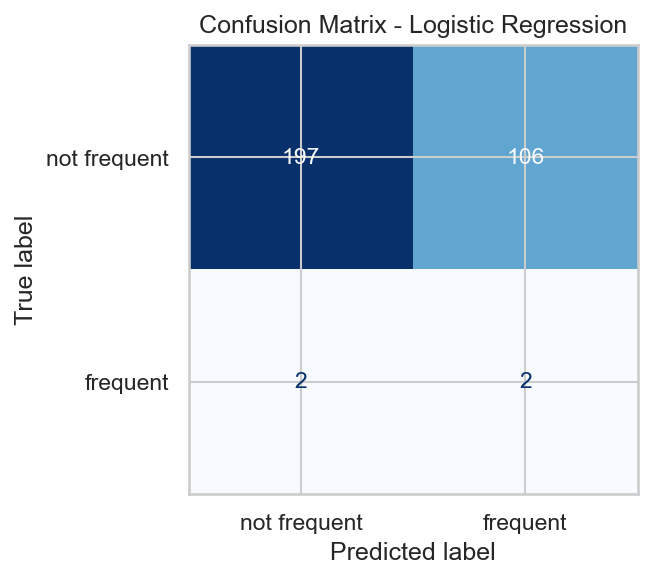

Saved: reports\figures\roc_curve_logistic_regression.png
Saved: images\roc_curve_logistic_regression.png


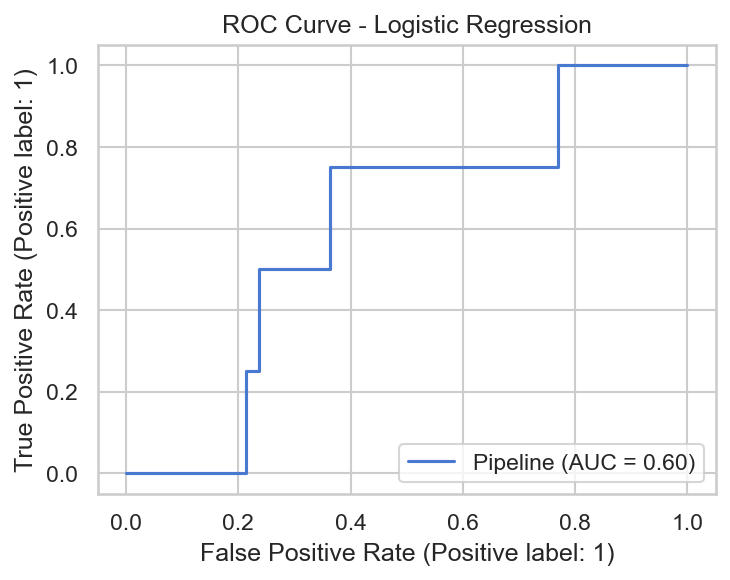

Saved: reports\figures\pr_curve_logistic_regression.png
Saved: images\pr_curve_logistic_regression.png


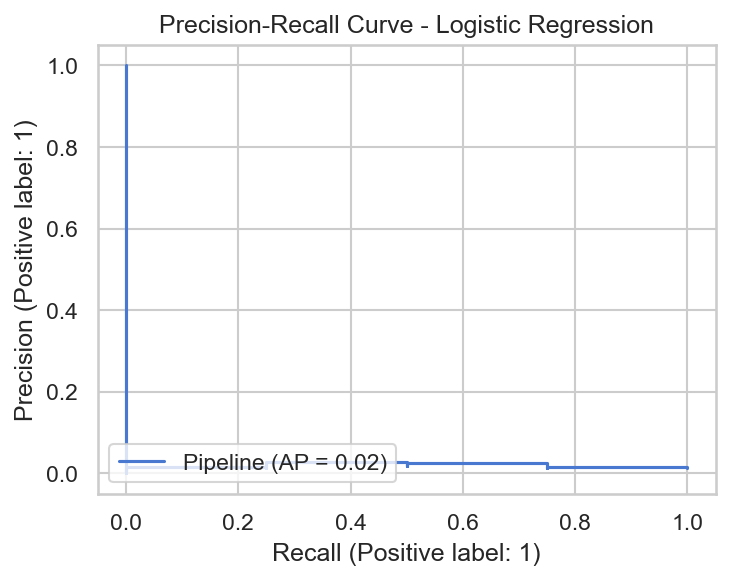

Saved: reports\figures\confusion_matrix_naive_bayes.png
Saved: images\confusion_matrix_naive_bayes.png


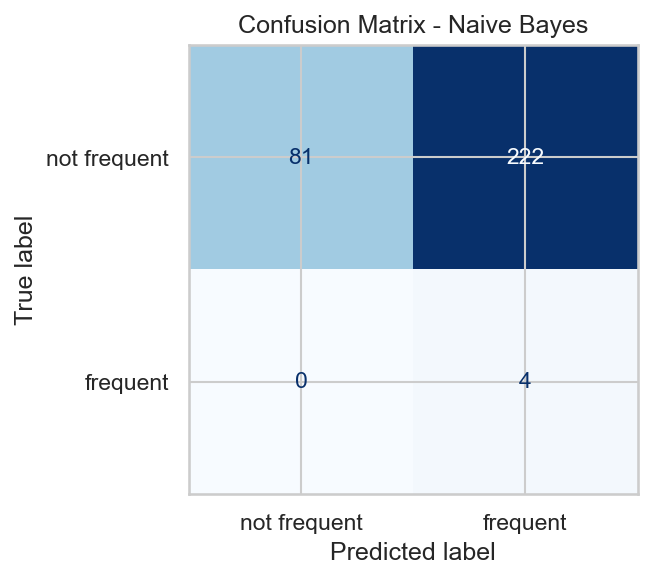

Saved: reports\figures\roc_curve_naive_bayes.png
Saved: images\roc_curve_naive_bayes.png


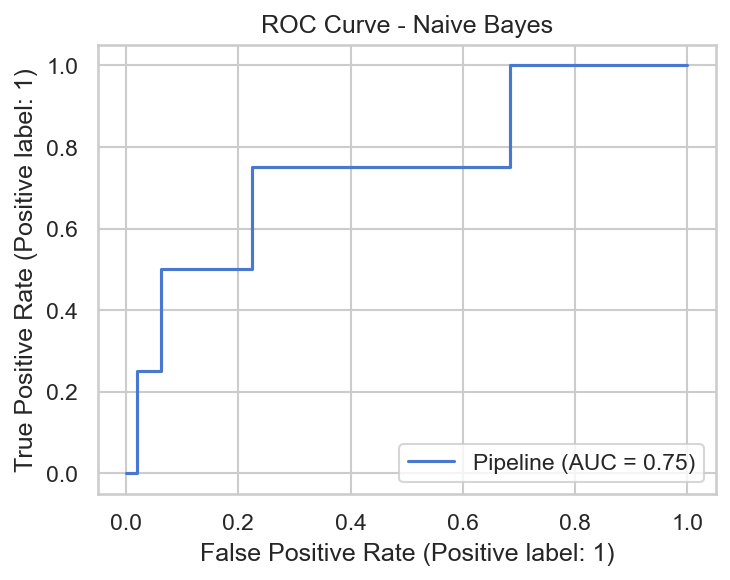

Saved: reports\figures\pr_curve_naive_bayes.png
Saved: images\pr_curve_naive_bayes.png


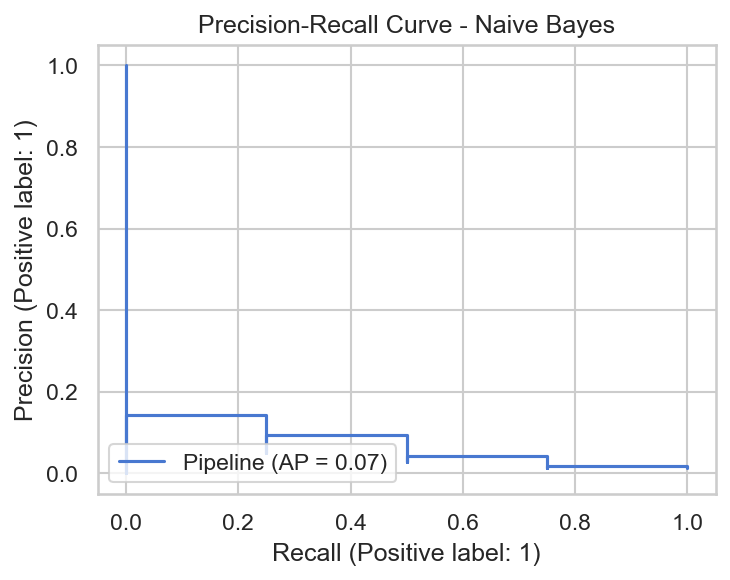

Saved: reports\figures\confusion_matrix_decision_tree.png
Saved: images\confusion_matrix_decision_tree.png


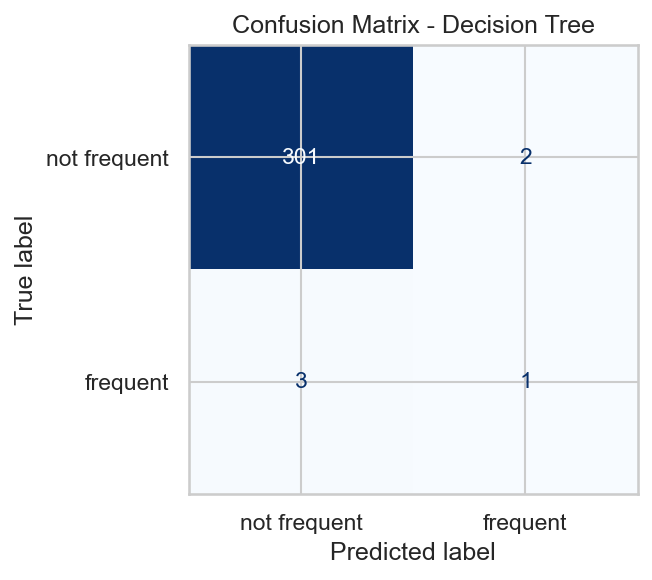

Saved: reports\figures\roc_curve_decision_tree.png
Saved: images\roc_curve_decision_tree.png


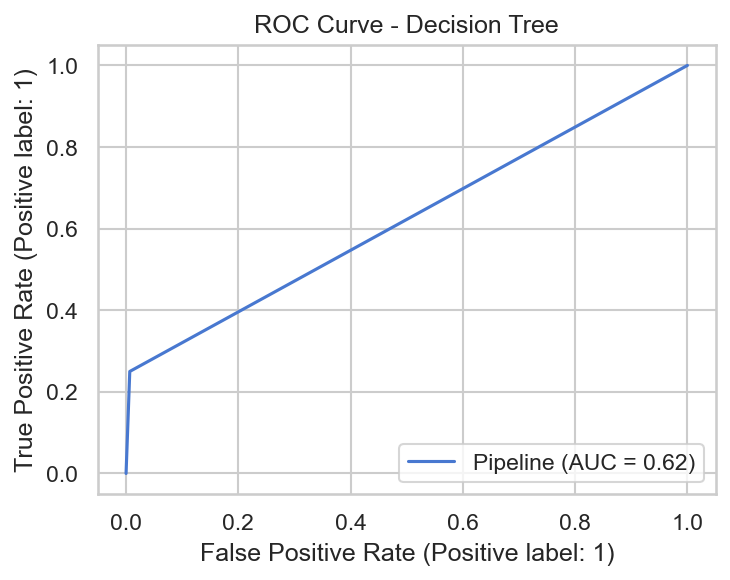

Saved: reports\figures\pr_curve_decision_tree.png
Saved: images\pr_curve_decision_tree.png


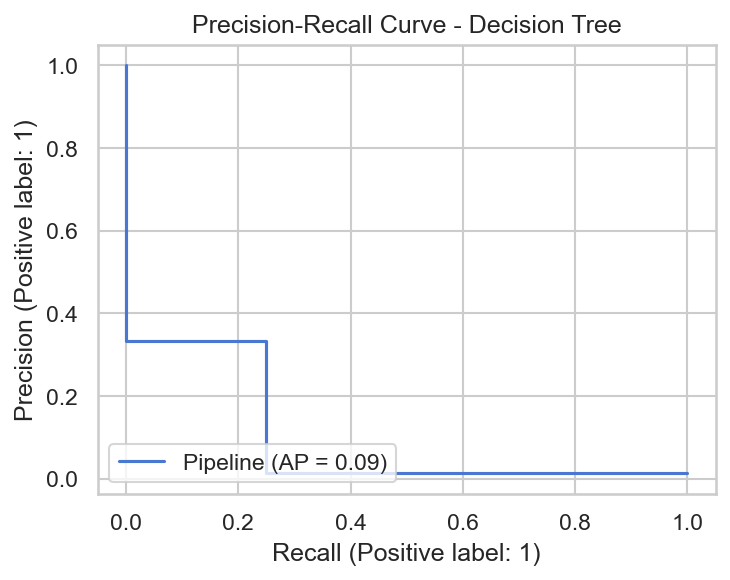

Saved: reports\figures\confusion_matrix_random_forest.png
Saved: images\confusion_matrix_random_forest.png


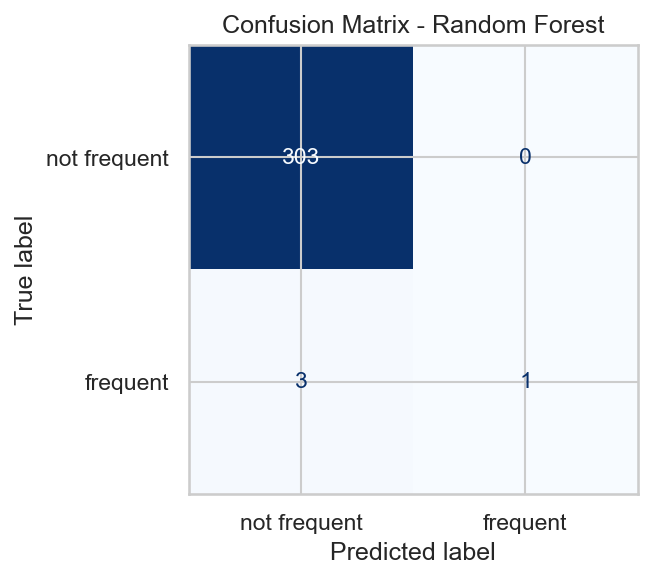

Saved: reports\figures\roc_curve_random_forest.png
Saved: images\roc_curve_random_forest.png


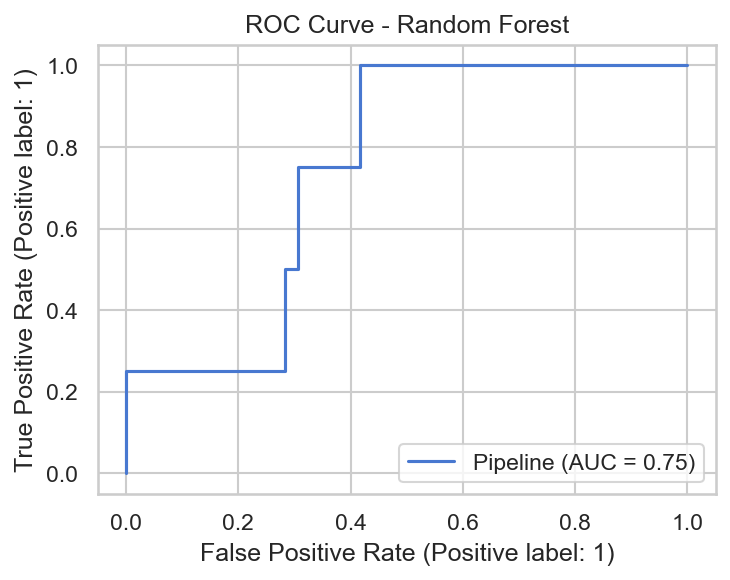

Saved: reports\figures\pr_curve_random_forest.png
Saved: images\pr_curve_random_forest.png


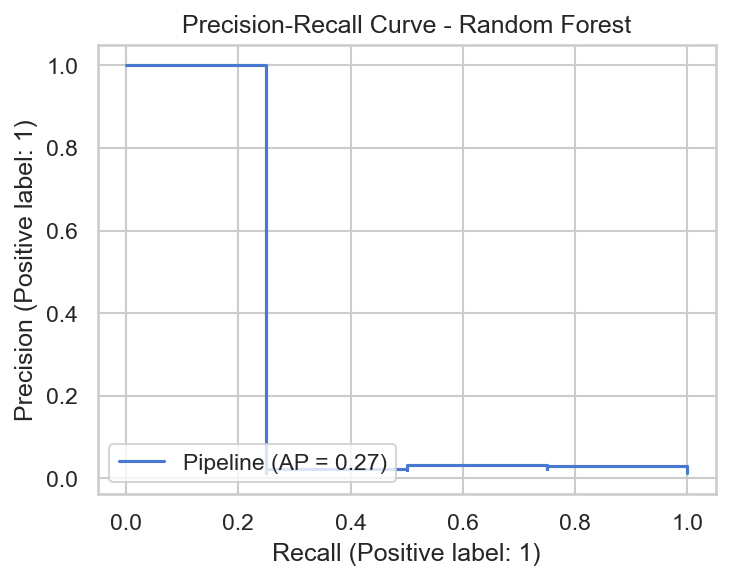

Saved: reports\figures\confusion_matrix_support_vector_machine.png
Saved: images\confusion_matrix_support_vector_machine.png


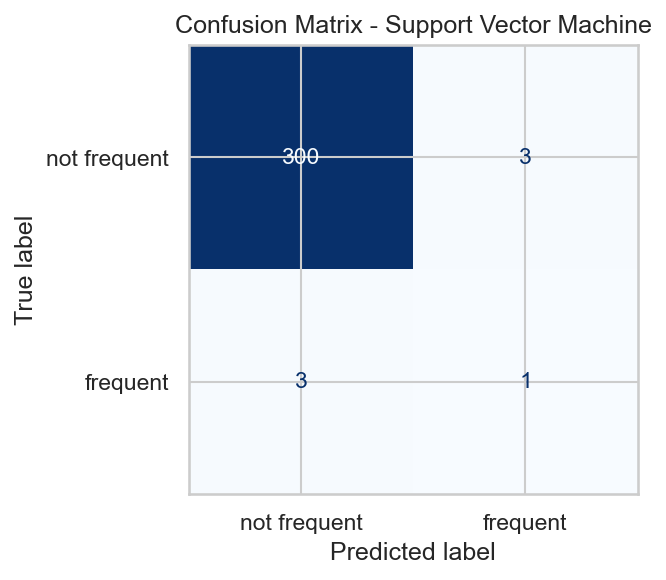

Saved: reports\figures\roc_curve_support_vector_machine.png
Saved: images\roc_curve_support_vector_machine.png


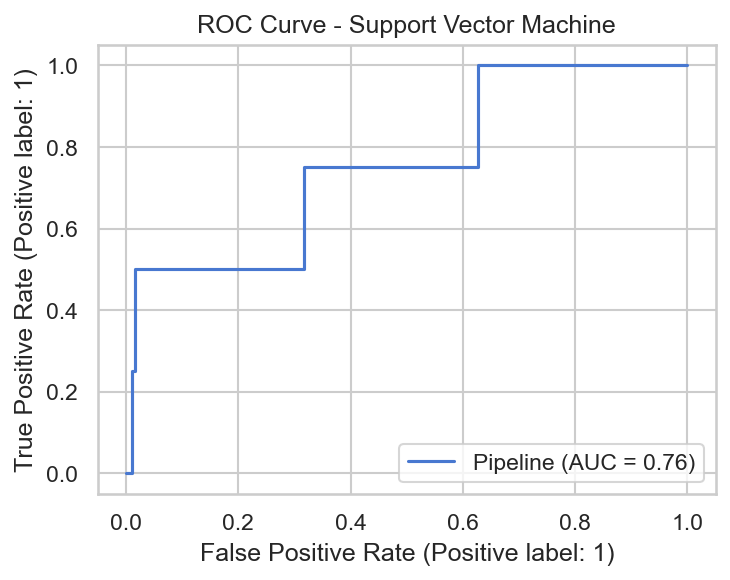

Saved: reports\figures\pr_curve_support_vector_machine.png
Saved: images\pr_curve_support_vector_machine.png


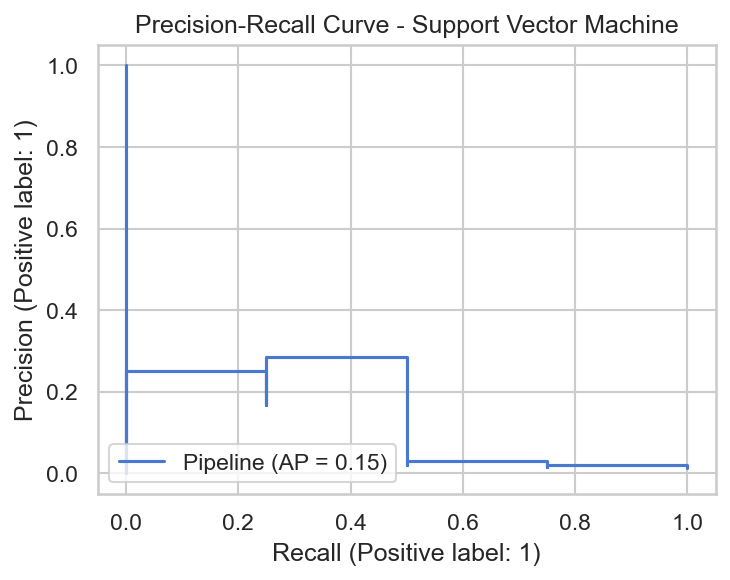

Saved: reports\figures\confusion_matrix_gradient_boosting.png
Saved: images\confusion_matrix_gradient_boosting.png


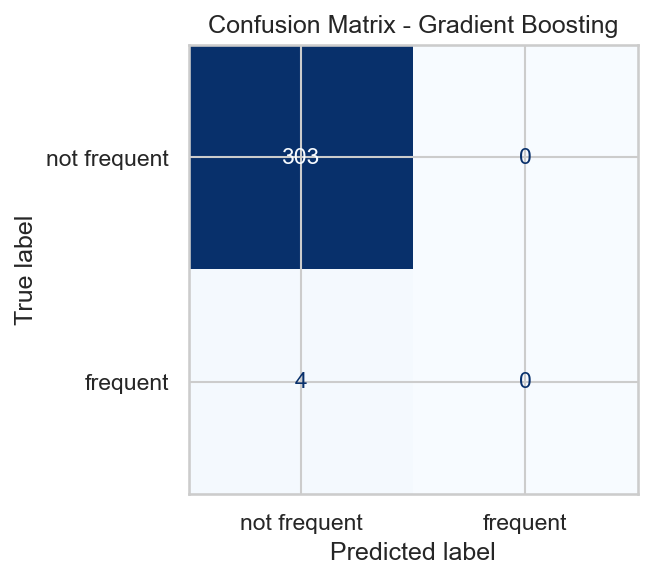

Saved: reports\figures\roc_curve_gradient_boosting.png
Saved: images\roc_curve_gradient_boosting.png


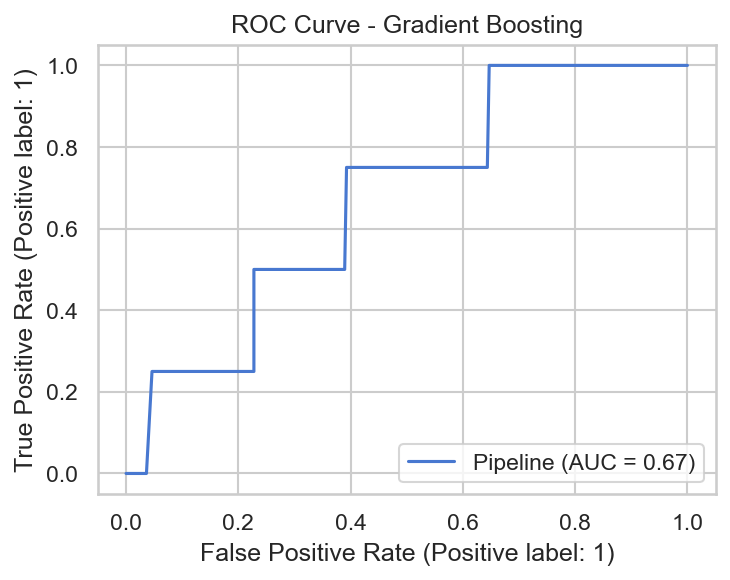

Saved: reports\figures\pr_curve_gradient_boosting.png
Saved: images\pr_curve_gradient_boosting.png


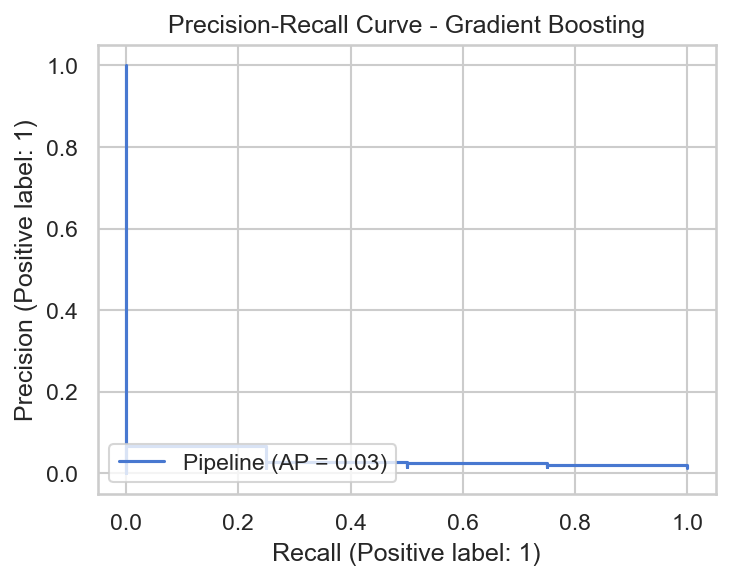

Saved: reports\figures\confusion_matrix_adaboost.png
Saved: images\confusion_matrix_adaboost.png


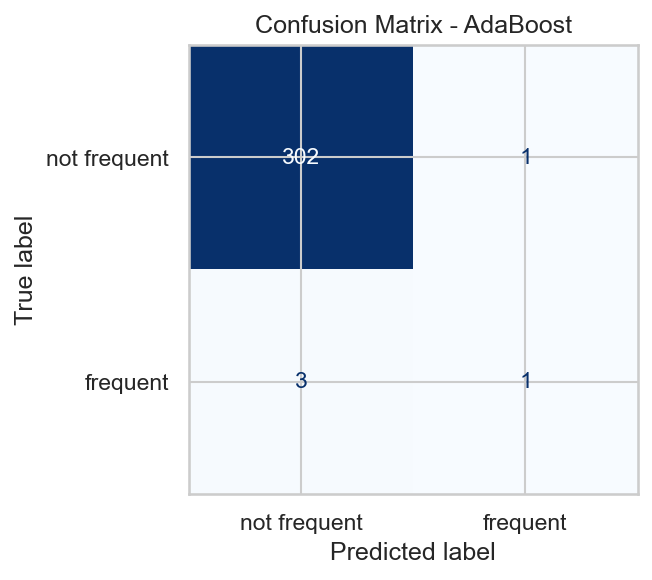

Saved: reports\figures\roc_curve_adaboost.png
Saved: images\roc_curve_adaboost.png


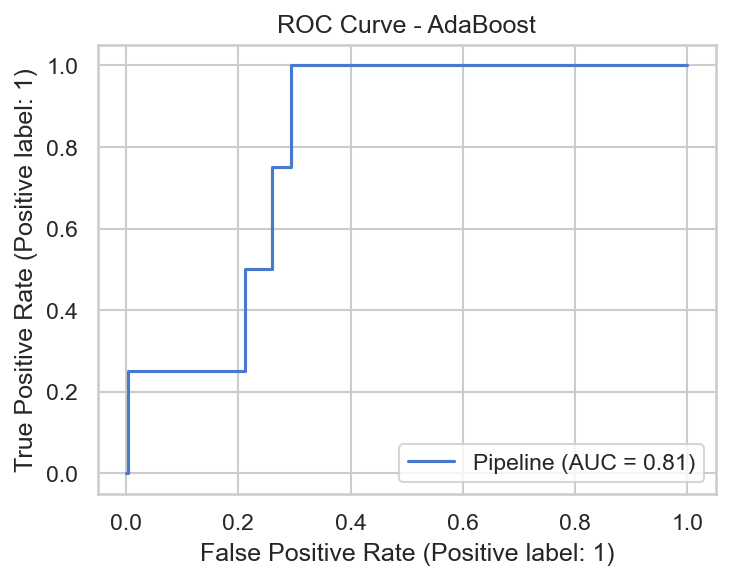

Saved: reports\figures\pr_curve_adaboost.png
Saved: images\pr_curve_adaboost.png


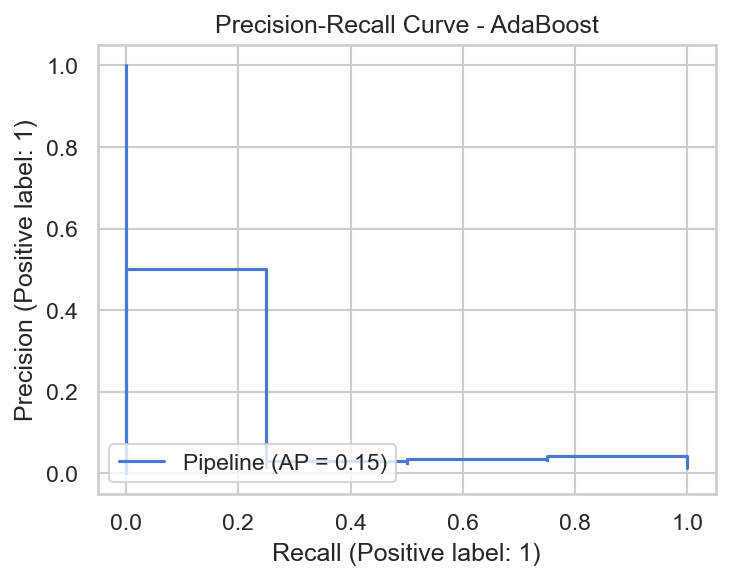


Classification report - Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.65      0.78       303
           1       0.02      0.50      0.04         4

    accuracy                           0.65       307
   macro avg       0.50      0.58      0.41       307
weighted avg       0.98      0.65      0.78       307


Classification report - Naive Bayes
              precision    recall  f1-score   support

           0       1.00      0.27      0.42       303
           1       0.02      1.00      0.03         4

    accuracy                           0.28       307
   macro avg       0.51      0.63      0.23       307
weighted avg       0.99      0.28      0.42       307


Classification report - Decision Tree
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       303
           1       0.33      0.25      0.29         4

    accuracy                           0.98       307
   macr

In [12]:
def slugify(value):
    return re.sub(r"[^a-z0-9]+", "_", value.lower()).strip("_")


def continuous_scores(estimator, X_values):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X_values)[:, 1]
    if hasattr(estimator, "decision_function"):
        return estimator.decision_function(X_values)
    return None


evaluation_rows = []
classification_reports = {}

for model_name, estimator in tuned_models.items():
    slug = slugify(model_name)
    y_pred = estimator.predict(X_test)
    y_score = continuous_scores(estimator, X_test)

    row = {
        "Model name": model_name,
        "Test accuracy": accuracy_score(y_test, y_pred),
        "Test precision": precision_score(y_test, y_pred, zero_division=0),
        "Test recall": recall_score(y_test, y_pred, zero_division=0),
        "Test F1": f1_score(y_test, y_pred, zero_division=0),
        "Balanced accuracy": balanced_accuracy_score(y_test, y_pred),
        "ROC-AUC": np.nan,
    }
    if y_score is not None and y_test.nunique() == 2:
        row["ROC-AUC"] = roc_auc_score(y_test, y_score)

    evaluation_rows.append(row)
    classification_reports[model_name] = classification_report(y_test, y_pred, zero_division=0)

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["not frequent", "frequent"],
        cmap="Blues",
        ax=ax,
        colorbar=False,
    )
    ax.set_title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    save_current_figure(f"confusion_matrix_{slug}.png")
    plt.show()

    if y_score is not None and y_test.nunique() == 2:
        fig, ax = plt.subplots(figsize=(5, 4))
        RocCurveDisplay.from_estimator(estimator, X_test, y_test, ax=ax)
        ax.set_title(f"ROC Curve - {model_name}")
        plt.tight_layout()
        save_current_figure(f"roc_curve_{slug}.png")
        plt.show()

        fig, ax = plt.subplots(figsize=(5, 4))
        PrecisionRecallDisplay.from_estimator(estimator, X_test, y_test, ax=ax)
        ax.set_title(f"Precision-Recall Curve - {model_name}")
        plt.tight_layout()
        save_current_figure(f"pr_curve_{slug}.png")
        plt.show()

for model_name, report in classification_reports.items():
    print(f"\nClassification report - {model_name}")
    print(report)


## Model Comparison

The comparison table combines tuning metadata and held-out test metrics. The table is saved as CSV for reporting, and the metric plot is saved to `reports/figures/model_comparison.png`.


,Model name,Best parameters,CV score,Training notes,Strengths,Weaknesses,Test accuracy,Test precision,Test recall,Test F1,Balanced accuracy,ROC-AUC
0,Random Forest,"{'class_weight': 'balanced', 'max_depth': 10, ...",0.100000,Bagging ensemble of decision trees.,Robust nonlinear model with feature importance.,Less transparent than a single tree and can st...,0.990228,1.000000,0.25,0.400000,0.625000,0.748350
1,AdaBoost,"{'learning_rate': 0.5, 'n_estimators': 100}",0.057143,Boosting ensemble using adaptive reweighting.,Useful aggregation method for weak learners.,Can be sensitive to noisy observations and out...,0.986971,0.500000,0.25,0.333333,0.623350,0.807756
2,Decision Tree,"{'class_weight': 'balanced', 'max_depth': None...",0.050000,Nonlinear tree model tuned for depth and leaf ...,Easy to interpret and captures feature thresho...,Can overfit when unconstrained.,0.983713,0.333333,0.25,0.285714,0.621700,0.621700
3,Support Vector Machine,"{'C': 10.0, 'class_weight': 'balanced', 'kerne...",0.133333,Margin-based classifier with linear and RBF ke...,Effective in compact feature spaces after scal...,Less interpretable and can be sensitive to tun...,0.980456,0.250000,0.25,0.250000,0.620050,0.757426
4,Logistic Regression,"{'C': 0.1, 'class_weight': 'balanced'}",0.032591,Linear baseline with regularization and option...,Interpretable coefficients; strong baseline fo...,May miss nonlinear relationships between audio...,0.648208,0.018519,0.50,0.035714,0.575083,0.603960
5,Naive Bayes,{'var_smoothing': 1e-07},0.025844,Probabilistic baseline with a Gaussian likelih...,Fast and useful as a simple benchmark on small...,Assumes conditional independence and Gaussian ...,0.276873,0.017699,1.00,0.034783,0.633663,0.752475
6,Gradient Boosting,"{'learning_rate': 0.05, 'max_depth': 2, 'n_est...",0.000000,Sequential boosting ensemble for nonlinear pat...,Often strong on tabular data with interactions.,Can overfit if too many weak learners are used.,0.986971,0.000000,0.00,0.000000,0.500000,0.673680


Saved: reports\figures\model_comparison.png
Saved: images\model_comparison.png


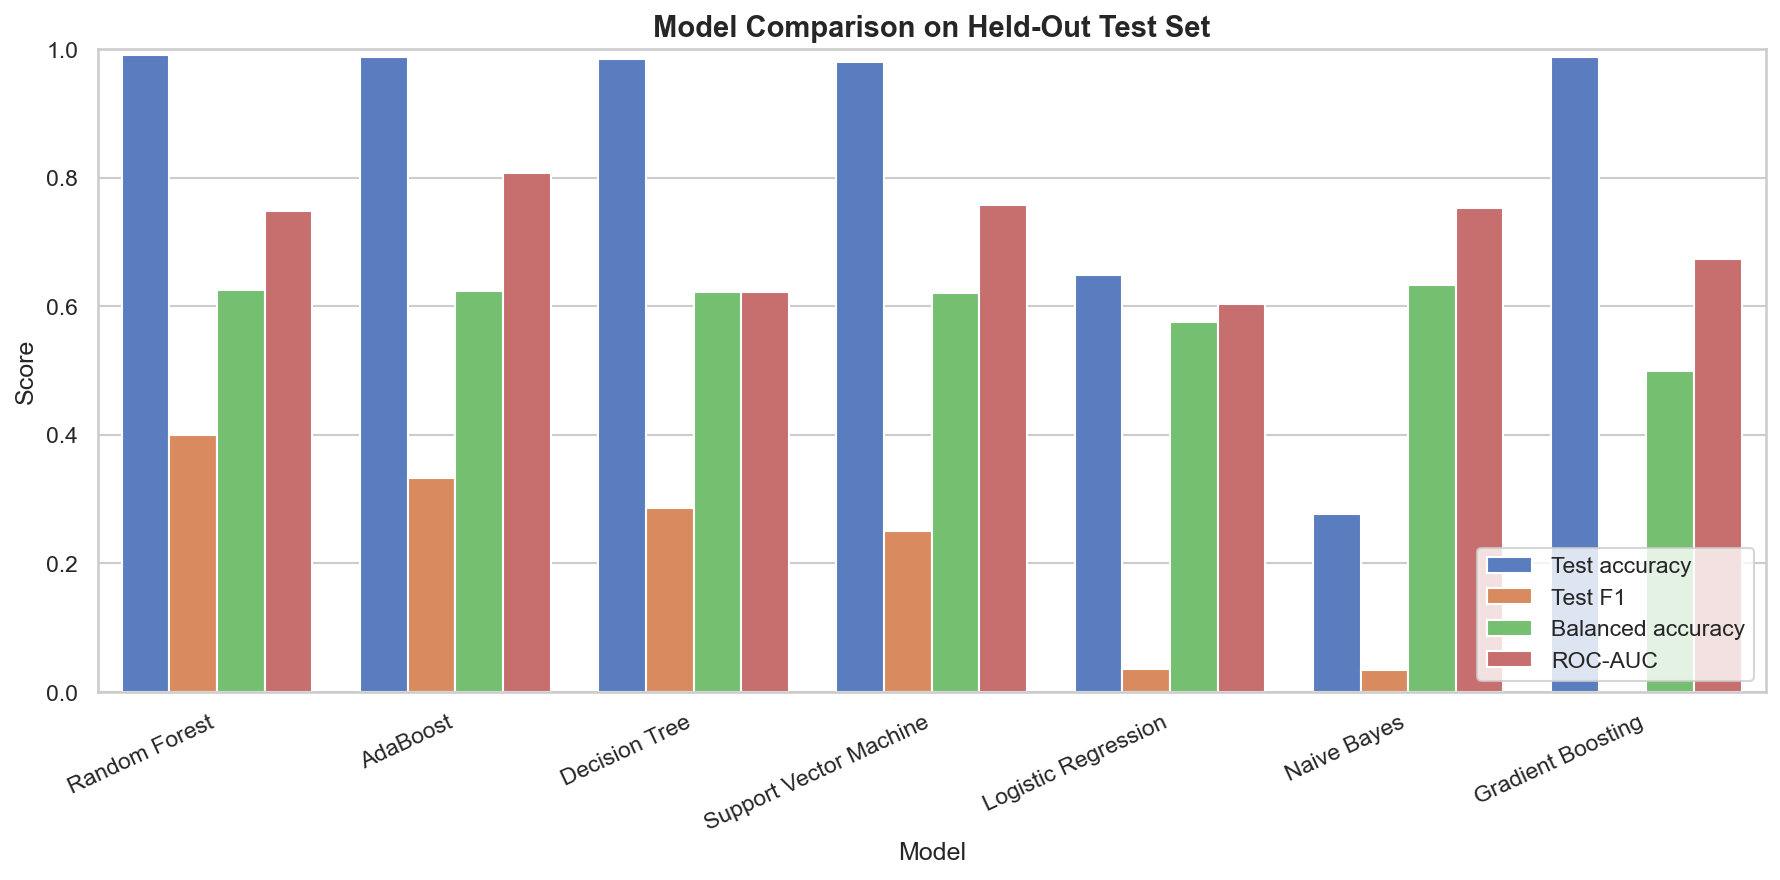

In [13]:
grid_summary_df = pd.DataFrame(grid_summaries)
evaluation_df = pd.DataFrame(evaluation_rows)
model_comparison = grid_summary_df.merge(evaluation_df, on="Model name", how="left")

metric_columns = ["CV score", "Test accuracy", "Test precision", "Test recall", "Test F1", "Balanced accuracy", "ROC-AUC"]
model_comparison[metric_columns] = model_comparison[metric_columns].astype(float)
model_comparison = model_comparison.sort_values(by="Test F1", ascending=False).reset_index(drop=True)

display(model_comparison)
model_comparison.to_csv(FIGURE_DIR.parent / "model_comparison_table.csv", index=False)

plot_df = model_comparison[["Model name", "Test accuracy", "Test F1", "Balanced accuracy", "ROC-AUC"]].melt(
    id_vars="Model name",
    var_name="Metric",
    value_name="Score",
)
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=plot_df, x="Model name", y="Score", hue="Metric", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("Model Comparison on Held-Out Test Set", fontsize=14, fontweight="bold")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
plt.xticks(rotation=25, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
save_current_figure("model_comparison.png")
plt.show()


,Feature,Importance
8,tempo,0.155229
4,energy,0.131200
6,acousticness,0.122420
5,loudness,0.104407
7,valence,0.099315
1,instrumentalness,0.094230
2,liveness,0.070468
0,speechiness,0.067281
3,danceability,0.053850
9,mode,0.037335


Saved: reports\figures\feature_importance_random_forest.png
Saved: images\feature_importance_random_forest.png


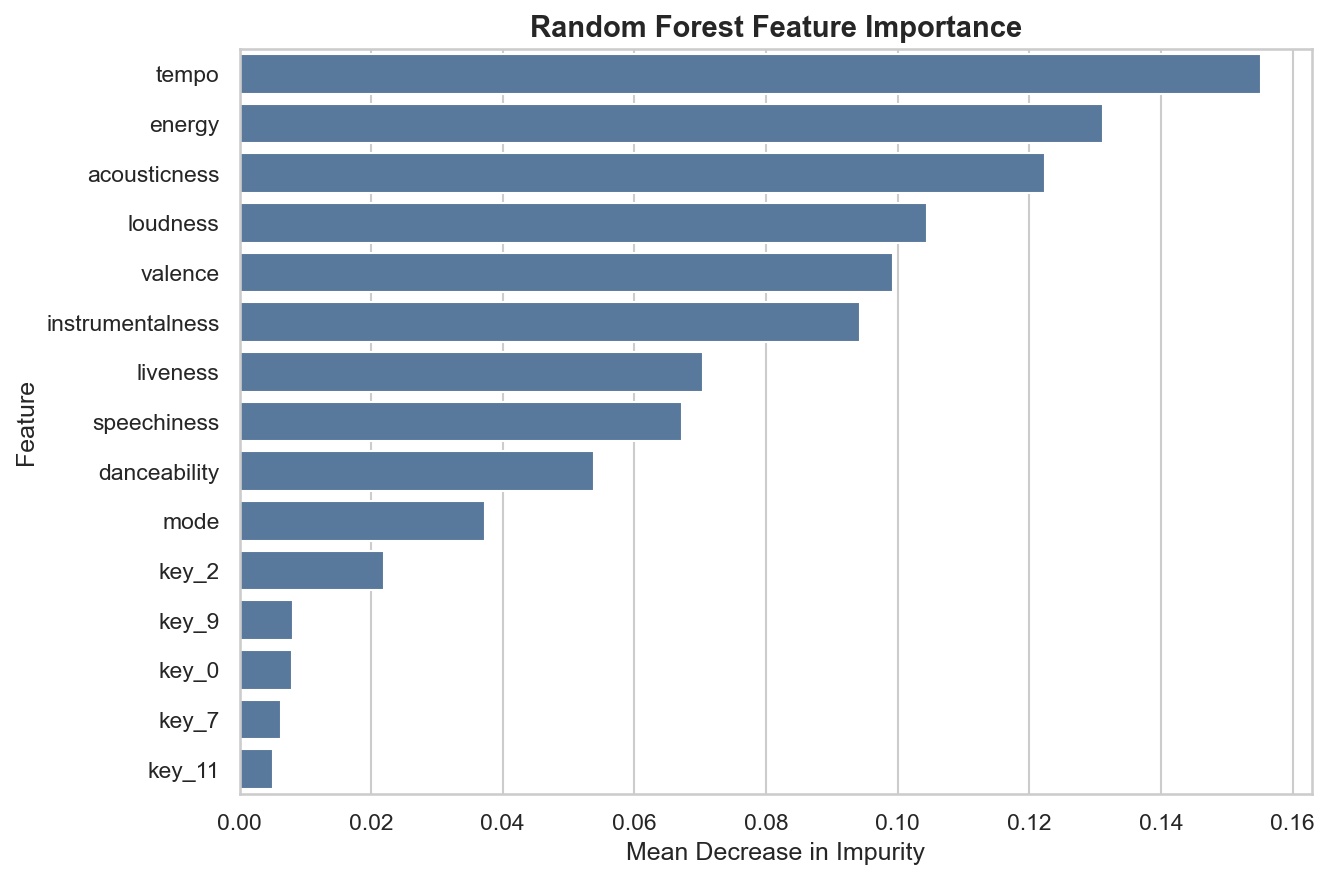

,Feature,Coefficient,abs_coef
12,key_2,1.229073,1.229073
9,mode,-1.005343,1.005343
21,key_11,-0.944234,0.944234
10,key_0,0.908927,0.908927
18,key_8,-0.783069,0.783069
20,key_10,-0.770734,0.770734
4,energy,-0.698265,0.698265
5,loudness,0.660737,0.660737
8,tempo,0.519622,0.519622
14,key_4,0.510344,0.510344


In [14]:
def get_preprocessed_feature_names(fitted_preprocessor):
    names = []
    for transformer_name, transformer, columns in fitted_preprocessor.transformers_:
        if transformer_name == "remainder" or transformer == "drop":
            continue
        columns = list(columns)
        if transformer_name == "nominal":
            onehot = transformer.named_steps["onehot"]
            names.extend(onehot.get_feature_names_out(columns).tolist())
        else:
            names.extend(columns)
    return names

rf_pipeline = tuned_models.get("Random Forest")
if rf_pipeline is not None:
    rf_model = rf_pipeline.named_steps["model"]
    feature_names = get_preprocessed_feature_names(rf_pipeline.named_steps["preprocess"])
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": rf_model.feature_importances_,
    }).sort_values("Importance", ascending=False)

    display(importance_df.head(20))
    importance_df.to_csv(FIGURE_DIR.parent / "feature_importance_random_forest.csv", index=False)

    fig, ax = plt.subplots(figsize=(9, 6))
    sns.barplot(data=importance_df.head(15), x="Importance", y="Feature", ax=ax, color="#4C78A8")
    ax.set_title("Random Forest Feature Importance", fontsize=14, fontweight="bold")
    ax.set_xlabel("Mean Decrease in Impurity")
    ax.set_ylabel("Feature")
    plt.tight_layout()
    save_current_figure("feature_importance_random_forest.png")
    plt.show()

lr_pipeline = tuned_models.get("Logistic Regression")
if lr_pipeline is not None:
    lr_model = lr_pipeline.named_steps["model"]
    feature_names = get_preprocessed_feature_names(lr_pipeline.named_steps["preprocess"])
    coef_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": lr_model.coef_[0],
    }).assign(abs_coef=lambda frame: frame["Coefficient"].abs()).sort_values("abs_coef", ascending=False)

    display(coef_df.head(20))
    coef_df.to_csv(FIGURE_DIR.parent / "logistic_regression_coefficients.csv", index=False)


## Interpretation

After running the notebook with the private JSON file, interpret the final model comparison table using these rules:

1. Prefer F1-score and balanced accuracy if the positive class is rare.
2. Use ROC-AUC only when the test set contains both classes and the estimator exposes probability or decision scores.
3. Treat track and artist text as high-risk identity metadata; audio-only results are more defensible for an academic claim about listening preference and audio features.
4. Feature importance from Random Forest and coefficients from Logistic Regression should be interpreted as model-specific associations, not causal effects.


## Conclusion and Next Steps

This notebook provides a reproducible Milestone 2 workflow: data loading, cleaning, leakage-aware feature engineering, sklearn preprocessing pipelines, stratified splitting, hyperparameter tuning, model evaluation, saved figures, and model comparison outputs.

**Next steps before final submission:**

- Run the full notebook locally with `gulcan_spotify_formatted.json` present.
- Verify that `reports/figures/confusion_matrix_logistic_regression.png`, `reports/figures/model_comparison.png`, and `reports/figures/feature_importance_random_forest.png` are generated.
- Update `reports/final_report/main.tex` by replacing red TODO notes with the actual best model and metric values.
- Re-check the GitHub repository after pushing to ensure duplicate notebook files are removed and the README instructions are clear.
